## Deconvolution using geneformer (pseudobulk + single-cell reference) - Cell2Sentence
This tutorial demonstrates how to use DECONVersation to run and evaluate deconvolution on pseudobulk data, using built-in pseudobulk simulation functions available within the package. Cell2Sentence embeddings are used throughout, though the workflow is fully adaptable to Geneformer or CellHermes. The tutorial covers the full pipeline: generating pseudobulk data, constructing signature matrices, extracting Geneformer embeddings from both the pseudobulk and single-cell reference signature datasets, and estimating cell type proportions via NNLS. Predicted proportions are then evaluated against ground truth using RMSE and Pearson correlation to benchmark deconvolution performance. <br>

### Step 0: Load reference data (scRNA-seq)

In [1]:
# Append path to deconversation modules
import sys
import os
import scanpy as sc
sys.path.append('../deconversation')

In [9]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Import associated modules
from pseudobulk import *
from preprocessing import *

In [3]:
# Path to single-cell RNAseq data 
path = "/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/deconvBench/hao800_id.h5ad"

### Step 1: Prep data for Geneformer

Load data uing scanpy and prep data for geneformer. `load_and_prep_data()` prepares the loaded anndata for geneformer by populating expected variables required by geneformer architecture.  Here we pass `mode = "geneformer"` since this is a geneformer based tutorial. However, if using cell2setence pass `mode = "c2s"`.

In [4]:
# Read the h5ad file (just to explore columns and variables)
adata = sc.read_h5ad(path)

# Subset to select cell types
adata = adata[adata.obs["broad_type"].isin(['B cells', 'Monocytes', 'NK cells', 'T cells'])]
adata = adata.copy()

# Remove unmapped genes
adata.var.index = adata.var["gene_name"]
adata = adata[:, adata.var.index.notnull()]

# Prep data for geneformer 
adata = load_and_prep_data(adata= adata, cell_type_col= "broad_type", mode="c2s", organism="Homo Sapiens")

/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/tutorials/../deconversation/preprocessing.py:82: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["organism"] = organism


### Step 2: Create pseudobulk

In [5]:
# Create pseudobulk and cell type prortions (ground truth)
pseudo_bulk, cell_prop = generate_pseudobulk(adata = adata,
                                             cell_type_col = "broad_type", # cell type column
                                             n_pseudobulks = 500, # Number of pseudobulk samples to be created
                                             target_proportion_min = 0.1, # expected min cell type proportion
                                             target_proportion_max = 0.80, # expected max cell type proportion
                                             n_cells_per_pseudobulk = 300, # number of cells to be used for pseudobulking per sample
                                             random_state = 42 # random state for reproducibility
                                            )

### Step 3: Create signature matrix

In [6]:
# Create signature matrix from single cell data
sig_mat = create_signature_matrix(adata = adata,
                                  sample_col = "batch", # sample id column
                                  celltype_col = "broad_type",
                                  groupby = "broad_type",
                                  sample_ids = None,
                                  output_path = None)

# Transpose for embedding extraction
# Columns should be gene names or ensembl ids (ensembl ids for geneformer)
sig_mat = sig_mat.T

/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/tutorials/../deconversation/preprocessing.py:239: UserWarning: Expression matrix contains non-integer values. Raw counts are expected. 
  warnings.warn(


The signature matrix is constructed by averaging gene expression across the selected cell types, requiring no predefined gene markers. To build a signature matrix from a specific subset of samples, pass the desired sample IDs as a list. Here, all available samples are used, so `sample_id` is set to None.

### Step 4: Extract Geneformer Embeddings

In [7]:
from embeddings import *

geneformer is not installed. Skipping related functions.


/nfs/sw/easybuild/software/custom-conda/cell2sentence-1.0/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cell2sentence successfully imported.
cellhermes is not installed. Skipping related functions.
scGPT is not installed. Skipping related functions.


In [10]:
sig_mat_c2s_embed = extract_embs(
    bulk_df = sig_mat, # sample x ensembl id
    mode = "c2s", 
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/deconvBench/pbmc/c2s/2b/2026-02-02-13_12_05_finetune_cell_type_prediction/checkpoint-3800", 
    delete_temp_files = True # if True, delete all temporary files created whiile extracting embeddings
)

WARN: more variables (21692) than observations (4)... did you mean to transpose the object (e.g. adata.T)?
WARN: more variables (21692) than observations (4), did you mean to transpose the object (e.g. adata.T)?
Saving the dataset (1/1 shards): 100%|██████████| 4/4 [00:00<00:00, 1514.74 examples/s]


Using device: cpu


Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  2.30it/s]


Reloading model from path on disk: /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/c2s_model


Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  2.33it/s]


Embedding 4 cells using CSModel...


100%|██████████| 4/4 [00:20<00:00,  5.16s/it]


In [11]:
pseudo_bulk_embed = extract_embs(
    bulk_df = pseudo_bulk, # sample x ensembl id
    mode = "c2s",
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/deconvBench/pbmc/c2s/2b/2026-02-02-13_12_05_finetune_cell_type_prediction/checkpoint-3800", 
    delete_temp_files = True
)

WARN: more variables (21692) than observations (500)... did you mean to transpose the object (e.g. adata.T)?
WARN: more variables (21692) than observations (500), did you mean to transpose the object (e.g. adata.T)?
Saving the dataset (1/1 shards): 100%|██████████| 500/500 [00:00<00:00, 29634.60 examples/s]


Using device: cpu


Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  2.32it/s]


Reloading model from path on disk: /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/c2s_model


Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  2.34it/s]


Embedding 500 cells using CSModel...


100%|██████████| 500/500 [44:55<00:00,  5.39s/it]


### Step 5: Run Non-Negative Least Squares (NNLS)

In [12]:
from deconvolution import *

In [14]:
# Run NNLS
cell_prop_pred = run_deconv(bulk_df = pseudo_bulk_embed.T, #columns should be embedding dimensions
                            signature_df = sig_mat_c2s_embed.T, #columns should be embedding dimensions
                            normalize = True)

Using 2304 common features.
Running deconvolution...


### Step 6: Evaluate estimated proportions

In [15]:
from evaluation import *

In [16]:
cell_prop.head()

,NK cells,T cells,Monocytes,B cells
T cells_PB1,0.216667,0.363333,0.236667,0.183333
B cells_PB2,0.053333,0.090000,0.090000,0.766667
T cells_PB3,0.123333,0.613333,0.130000,0.133333
Monocytes_PB4,0.156667,0.146667,0.520000,0.176667
T cells_PB5,0.276667,0.210000,0.233333,0.280000


In [17]:
#Compute RMSE per cell type
rmse_per_cell_type = compute_rmse(true_df = cell_prop, # sample (rows) x cell type (columns)
                                 pred_df = cell_prop_pred, # sample (rows) x cell type (columns)
                                 return_per_celltype = True)

rmse_per_cell_type = pd.DataFrame(rmse_per_cell_type)

rmse_per_cell_type

,overall,per_celltype
NK cells,0.13978,0.139135
T cells,0.13978,0.178538
Monocytes,0.13978,0.094104
B cells,0.13978,0.134403


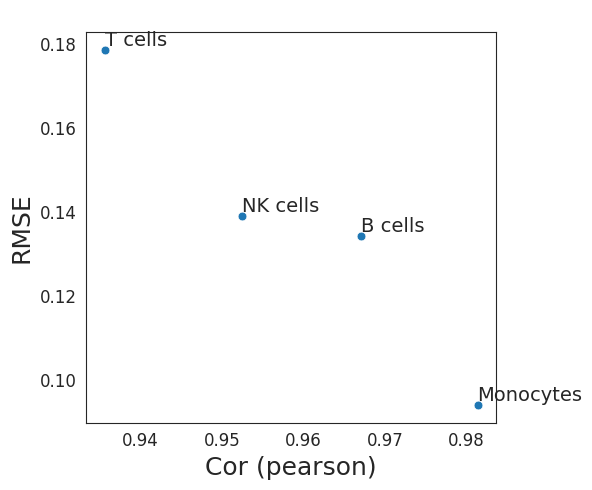

In [18]:
# Visualize RMSE - Correlation plot
# Both RMSE and Correlation coefficients are overall values (i.e not stratified by cell type)
sns.set_style("white")
plot_rmse_vs_corr_by_celltype(
    true_df = cell_prop,
    pred_df = cell_prop_pred
)

In [20]:
from visualization import *

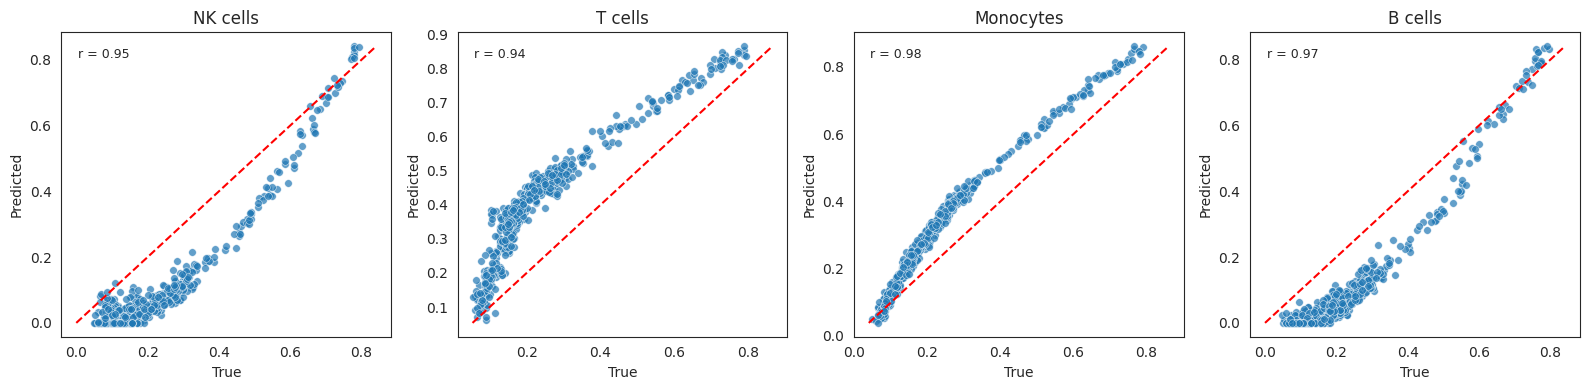

In [21]:
plot_true_vs_predicted(
    y_true_df = cell_prop, # sample (rows) x cell type (columns)
    y_pred_df = cell_prop_pred, # sample (rows) x cell type (columns)
    stratify_by_celltype= True,
    dot_size = 30,n_cols=4,
    figsize_per_plot = (4,4)
    
)

### Optional Step: Run Other Solvers

Using 2304 common features.
Running deconvolution...


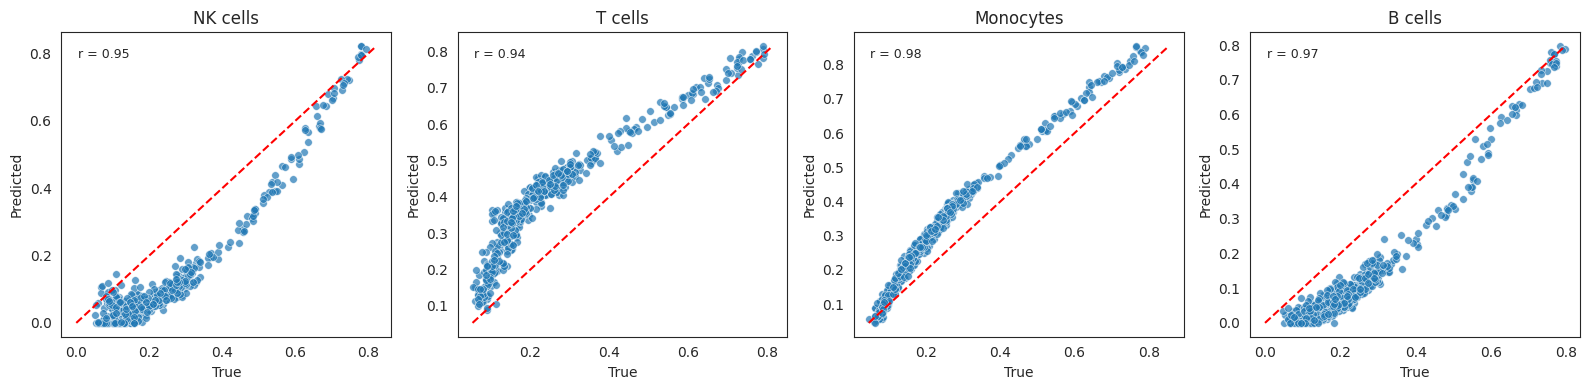

In [29]:
# Run ElasticNet
cell_prop_pred = run_deconv(bulk_df = pseudo_bulk_embed.T,
                                 signature_df = sig_mat_c2s_embed.T, 
                            solver= "elasticnet",
                                 normalize = True)

# Visualize 
plot_true_vs_predicted(
    y_true_df = cell_prop,
    y_pred_df = cell_prop_pred,
    stratify_by_celltype = True, 
    dot_size = 30,n_cols=4,
    figsize_per_plot = (4,4)
)

In [34]:
# Run NuSVR
cell_prop_pred = run_deconv(bulk_df = pseudo_bulk_embed.T,
                            signature_df = sig_mat_c2s_embed.T, 
                            solver= "nusvr",
                            normalize = True)

# Visualize 
plot_true_vs_predicted(
    y_true_df = cell_prop,
    y_pred_df = cell_prop_pred,
    stratify_by_celltype = True, 
    dot_size = 30,n_cols=4,
    figsize_per_plot = (4,4))

Using 2304 common features.
Running deconvolution...


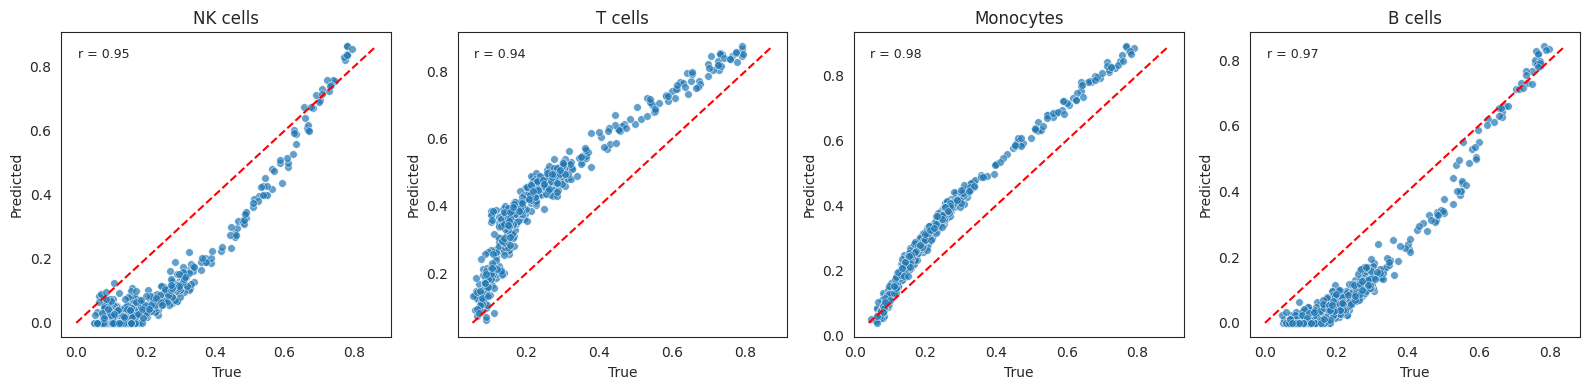

In [32]:
# Run ridge
cell_prop_pred = run_deconv(bulk_df = pseudo_bulk_embed.T,
                                 signature_df = sig_mat_c2s_embed.T, 
                            solver= "ridge",
                                 normalize = True)

# Visualize 
plot_true_vs_predicted(
    y_true_df = cell_prop,
    y_pred_df = cell_prop_pred,
    stratify_by_celltype = True, 
    dot_size = 30,n_cols=4,
    figsize_per_plot = (4,4)
)